**1. Data reconnaissance**

In [124]:
import pandas as pd

df = pd.read_csv('kaggle/input/datasets/algozee/teenager-menthal-healy/Teen_Mental_Health_Dataset.csv')

df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [125]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [126]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

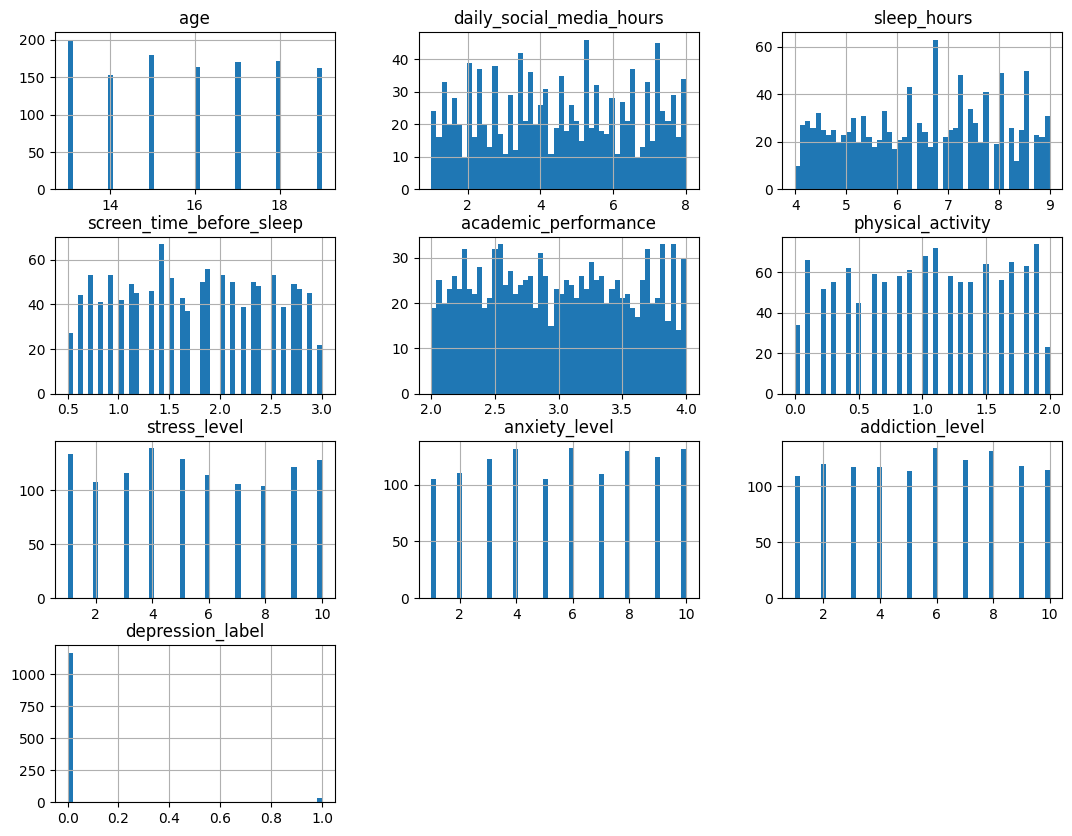

In [127]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(13,10))
plt.show() # Show histogram

**2. Changing data using an encoder**

In [128]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_columns = [
    'gender',
    'platform_usage',
    'social_interaction_level'
]

numeric_columns = [
    'age',
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'stress_level',
    'anxiety_level',
    'addiction_level'
]

# Numeric pipeline
numeric_transformer = Pipeline([
    ('poly', PolynomialFeatures(
        degree=3,
        include_bias=False
    )),
    ('scaler', StandardScaler())
])

# Full preprocessing
preprocessor = ColumnTransformer([
    (
        'num',
        numeric_transformer,
        numeric_columns
    ),
    (
        'cat',
        OneHotEncoder(handle_unknown='ignore'),
        categorical_columns
    )
])

**3. Split Data**

In [129]:
from sklearn.model_selection import train_test_split


train_data = df.drop('depression_label', axis=1)

test_data = df['depression_label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    train_data,
    test_data,
    test_size=0.2,      # 20% for test
    random_state=42,)

**4. Train model**

In [130]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced'
    ))
])

In [131]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

**5. Scores**

In [132]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Train model
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-score: {f1*100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 97.08%
Precision: 45.45%
Recall: 83.33%
F1-score: 58.82%

Confusion Matrix:
[[228   6]
 [  1   5]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       234
           1       0.45      0.83      0.59         6

    accuracy                           0.97       240
   macro avg       0.73      0.90      0.79       240
weighted avg       0.98      0.97      0.97       240



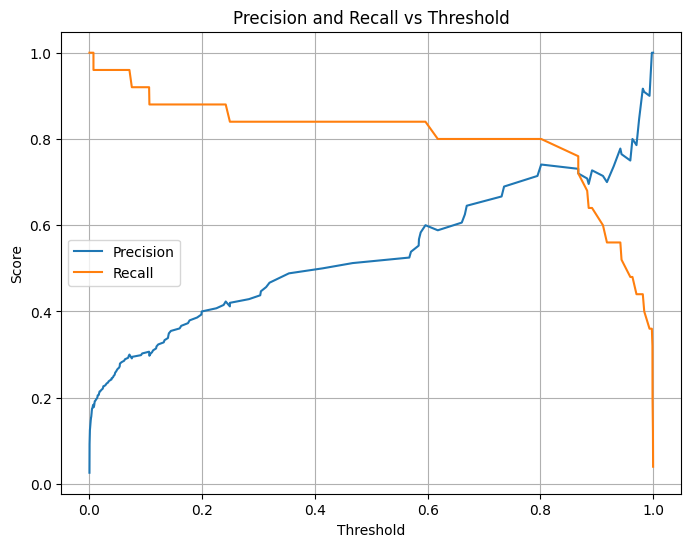

In [133]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(
    pipeline,
    X_train,
    y_train,
    cv=3,
    method='predict_proba'
)

y_scores = y_scores[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_train,
    y_scores
)

precision = precision[:-1]
recall = recall[:-1]

plt.figure(figsize=(8, 6))

plt.plot(thresholds, precision, label='Precision')
plt.plot(thresholds, recall, label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')

plt.legend()
plt.grid()

plt.show()

**6. For user**

In [134]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

slider_layout = widgets.Layout(width='500px')
style = {'description_width': '250px'}

print("Write your data:")

# ===== NUMERIC FEATURES =====
age = widgets.IntSlider(
    min=10, max=80, value=25,
    description='👤 Age (years)',
    layout=slider_layout,
    style=style
)

sleep_hours = widgets.FloatSlider(
    min=0, max=12, value=7,
    description='😴 Sleep (hours/day)',
    layout=slider_layout,
    style=style
)

daily_social_media_hours = widgets.FloatSlider(
    min=0, max=12, value=3,
    description='📱 Social media usage (hours/day)',
    layout=slider_layout,
    style=style
)

screen_time_before_sleep = widgets.FloatSlider(
    min=0, max=12, value=2,
    description='📺 Screen time before sleep',
    layout=slider_layout,
    style=style
)

academic_performance = widgets.IntSlider(
    min=0, max=10, value=5,
    description='🎓 Academic performance (0–10)',
    layout=slider_layout,
    style=style
)

physical_activity = widgets.IntSlider(
    min=0, max=10, value=5,
    description='🏃 Physical activity (0–10)',
    layout=slider_layout,
    style=style
)

stress_level = widgets.IntSlider(
    min=0, max=10, value=5,
    description='⚡ Stress level (0–10)',
    layout=slider_layout,
    style=style
)

anxiety_level = widgets.IntSlider(
    min=0, max=10, value=5,
    description='😟 Anxiety level (0–10)',
    layout=slider_layout,
    style=style
)

addiction_level = widgets.IntSlider(
    min=0, max=10, value=5,
    description='🔗 Addiction level (0–10)',
    layout=slider_layout,
    style=style
)

# ===== CATEGORICAL FEATURES =====
gender = widgets.Dropdown(
    options=['male', 'female'],
    description='🚻 Gender',
    layout=slider_layout,
    style=style
)

platform_usage = widgets.Dropdown(
    options=['instagram', 'tiktok', 'youtube', 'twitter'],
    description='📲 Main platform',
    layout=slider_layout,
    style=style
)

social_interaction_level = widgets.Dropdown(
    options=['low', 'medium', 'high'],
    description='👥 Social interaction level',
    layout=slider_layout,
    style=style
)

# ===== DISPLAY =====
display(
    age, sleep_hours, daily_social_media_hours,
    screen_time_before_sleep, academic_performance,
    physical_activity, stress_level, anxiety_level,
    addiction_level, gender, platform_usage, social_interaction_level
)

button = widgets.Button(description="Predict")
output = widgets.Output()

display(button, output)


# ===== PREDICTION =====
def predict(b):
    user_df = pd.DataFrame([{
        'age': age.value,
        'daily_social_media_hours': daily_social_media_hours.value,
        'sleep_hours': sleep_hours.value,
        'screen_time_before_sleep': screen_time_before_sleep.value,
        'academic_performance': academic_performance.value,
        'physical_activity': physical_activity.value,
        'stress_level': stress_level.value,
        'anxiety_level': anxiety_level.value,
        'addiction_level': addiction_level.value,
        'gender': gender.value,
        'platform_usage': platform_usage.value,
        'social_interaction_level': social_interaction_level.value
    }])

    user_df = user_df.reindex(columns=X_train.columns, fill_value=0)

    prob = pipeline.predict_proba(user_df)[0][1]

    with output:
        output.clear_output()
        print(f"Risk of depression: {prob * 100:.2f}%")

button.on_click(predict)

Write your data:


IntSlider(value=25, description='👤 Age (years)', layout=Layout(width='500px'), max=80, min=10, style=SliderSty…

FloatSlider(value=7.0, description='😴 Sleep (hours/day)', layout=Layout(width='500px'), max=12.0, style=Slider…

FloatSlider(value=3.0, description='📱 Social media usage (hours/day)', layout=Layout(width='500px'), max=12.0,…

FloatSlider(value=2.0, description='📺 Screen time before sleep', layout=Layout(width='500px'), max=12.0, style…

IntSlider(value=5, description='🎓 Academic performance (0–10)', layout=Layout(width='500px'), max=10, style=Sl…

IntSlider(value=5, description='🏃 Physical activity (0–10)', layout=Layout(width='500px'), max=10, style=Slide…

IntSlider(value=5, description='⚡ Stress level (0–10)', layout=Layout(width='500px'), max=10, style=SliderStyl…

IntSlider(value=5, description='😟 Anxiety level (0–10)', layout=Layout(width='500px'), max=10, style=SliderSty…

IntSlider(value=5, description='🔗 Addiction level (0–10)', layout=Layout(width='500px'), max=10, style=SliderS…

Dropdown(description='🚻 Gender', layout=Layout(width='500px'), options=('male', 'female'), style=DescriptionSt…

Dropdown(description='📲 Main platform', layout=Layout(width='500px'), options=('instagram', 'tiktok', 'youtube…

Dropdown(description='👥 Social interaction level', layout=Layout(width='500px'), options=('low', 'medium', 'hi…

Button(description='Predict', style=ButtonStyle())

Output()

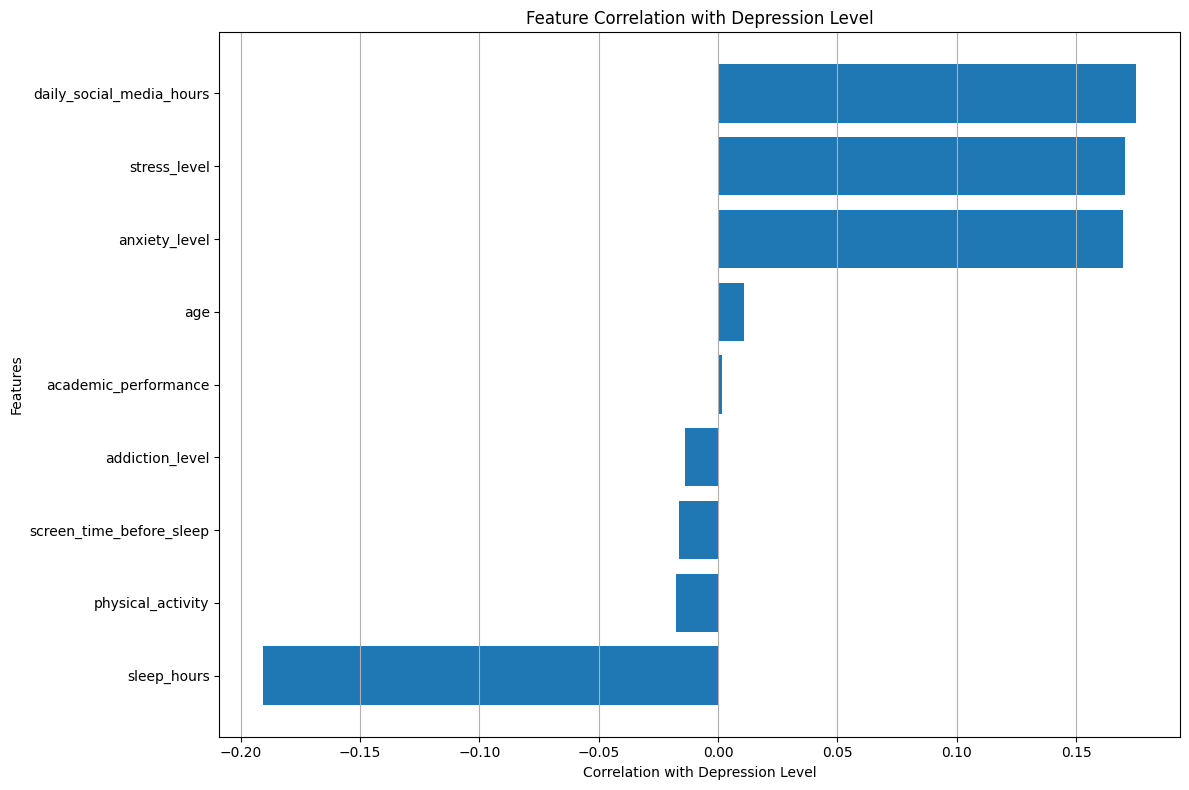

In [135]:
import matplotlib.pyplot as plt

# Calculate correlations with the target column
correlations = df.corr(numeric_only=True)['depression_label']

# Remove the target itself from the list
correlations = correlations.drop('depression_label')

# Sort features by correlation values
correlations = correlations.sort_values()

# Create figure
plt.figure(figsize=(12, 8))

# Create horizontal bar chart
plt.barh(
    correlations.index,
    correlations.values
)

# Axis labels
plt.xlabel('Correlation with Depression Level')
plt.ylabel('Features')

# Plot title
plt.title('Feature Correlation with Depression Level')

# Add grid for readability
plt.grid(axis='x')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.show()

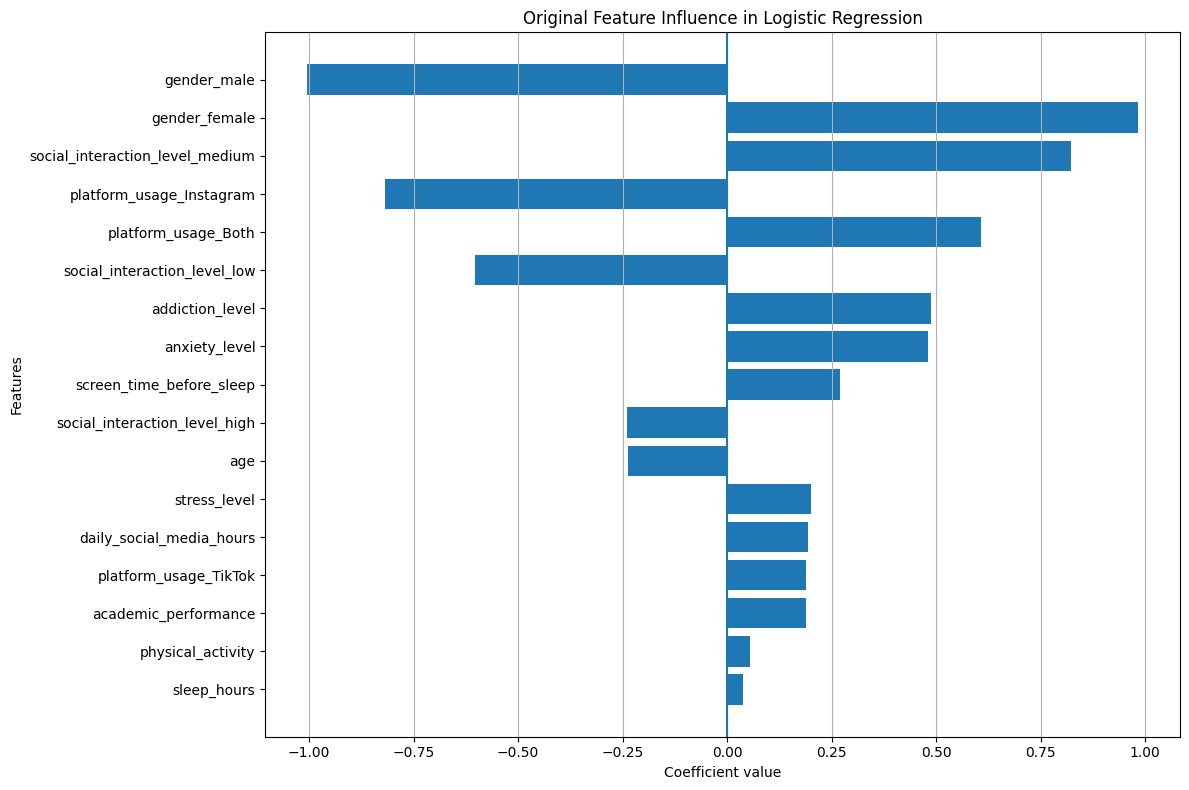

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

# Get transformed feature names
feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get model coefficients
coefficients = pipeline.named_steps[
    'model'
].coef_[0]

# Create dataframe
importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Remove polynomial features:
# '^' → powers (x²)
# ' ' → interactions (x*y)
importance = importance[
    ~importance['Feature'].str.contains(r'\^| ')
]

# Remove pipeline prefixes
importance['Feature'] = (
    importance['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

# Sort by influence
importance['Absolute'] = (
    importance['Coefficient'].abs()
)

importance = importance.sort_values(
    by='Absolute',
    ascending=True
)

# Create plot
plt.figure(figsize=(12,8))

plt.barh(
    importance['Feature'],
    importance['Coefficient']
)

plt.xlabel('Coefficient value')
plt.ylabel('Features')
plt.title('Original Feature Influence in Logistic Regression')

plt.axvline(0)

plt.grid(axis='x')

plt.tight_layout()

plt.show()